# Import

In [17]:
import numpy as np
import astropy
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import QTable

In [27]:
mass = 1.223   # solar mass
radius = 1.357   # solar radius
lum = mass**4   # solar lum
teff = 6325   # K

In [2]:
teff_sun = 5777   # K
width_sun = 0.95   # micro Hz (baudin et al 2011)
del_nu_sun = 134.91   # micro Hz  # source: lund et al (2016) (paper i)
nu_max_sun = 3090   # micro Hz   # source: huber et al (2011)
epsilon = 1.55   # joel found this
nu_ac_sun = 5000   # micro Hz (Jimenez et al 2011)

In [3]:
# source: chaplin & miglio (2013)
def large_separation():   # Δν
    del_nu = del_nu_sun*(mass**(1/2))*(radius**(-3/2))
    return del_nu

In [4]:
# source: chaplin & miglio (2013)
def mode_max():   # ν_max
    g = mass/(radius**2)
    nu_max = nu_max_sun*g*((teff/teff_sun)**(-1/2))
    return nu_max

In [53]:
# source: lund et al (2016)
def mode_freq():   # ν_nl
    order = [i for i in range(10,101)]   # n needs to be large
    degree = [i for i in range(0,4)]   # l only observable up to l<4
    del_nu = large_separation()
    
    # asymptotic relation
    modes = []
    for l in degree:
        if l % 2 == 0:
            D_0 = 1.   # fit by isaac
        elif l % 2 == 1:
            D_0 = 5/3   # ratio from chaplin & miglio (2013)
        for n in order:
            nu_nl = (n + l/2 + epsilon)*del_nu - l*(l + 1)*D_0
            modes.append((n, l, nu_nl))
    modes = np.array(modes, dtype=[("n", int), ("l", int), ("nu", float)])
    frequencies = np.array(modes["nu"])
    return frequencies


'''
def calc_nu_nl(self, n,l):
        """
        

        Parameters
        ----------
        n : int
            radial mode
        l : int
            angular degree

        Returns
        -------
        nu_nl : float
            frequency of the p-mode oscillations

        """
        
        #I have no actual idea how D relates to the splitting of the frequencies.
        #I have chucked in the relationship between delta nu_02 and delta nu.
        #In the asymptotic limit, dnu03 = 5/3 dnu02, which i have reflected here (Chaplin and Miglio 2013).
        #I'm gonna die
        
        # linear fit is from the Kepler LEGACY stars scatter plot, with some random Gaussian noise added in (parameters from star data).
        # Keen et al 2014 gives the second term (the frequency splitting term) to be simply the small frequency separation, hence what i have attempted here,
        # though they add it instead of subtracting it, i tested this and it made everything worse, though that may be due to the random element in fit
        
        # fit = (0.05200 * self.star_delta_nu) + np.random.normal(1.42683, 1.41997)
        # fit = (0.05200 * self.star_delta_nu) + 1.42683
        # fit = 3
        fit = 1.0
        # fit = 0
        
        if l % 2 == 0:
        
             nu_nl = self.star_delta_nu * ( n+(l/2) + self.epsilon) - fit * l * (l+1)
            
        elif l % 2 == 1:
            nu_nl = self.star_delta_nu * ( n+(l/2) + self.epsilon) - fit * (5/3) * l * (l+1)
            #nu_nl = self.star_delta_nu * ( n+(l/2) + self.epsilon) - fit * l * (l+1)
        
        return nu_nl
'''

'\ndef calc_nu_nl(self, n,l):\n        """\n\n\n        Parameters\n        ----------\n        n : int\n            radial mode\n        l : int\n            angular degree\n\n        Returns\n        -------\n        nu_nl : float\n            frequency of the p-mode oscillations\n\n        """\n\n        #I have no actual idea how D relates to the splitting of the frequencies.\n        #I have chucked in the relationship between delta nu_02 and delta nu.\n        #In the asymptotic limit, dnu03 = 5/3 dnu02, which i have reflected here (Chaplin and Miglio 2013).\n        #I\'m gonna die\n\n        # linear fit is from the Kepler LEGACY stars scatter plot, with some random Gaussian noise added in (parameters from star data).\n        # Keen et al 2014 gives the second term (the frequency splitting term) to be simply the small frequency separation, hence what i have attempted here,\n        # though they add it instead of subtracting it, i tested this and it made everything worse, thou

In [28]:
# source: ball et al (2018)
# maximum rms amplitude
def amp_rms_max():
    tred = 8907*(lum)**(-0.093)
    del_T = 1250
    beta = 1-np.exp((teff-tred)/del_T)
    amp_max = 2.1*beta*lum*(1/mass)*((teff/teff_sun)**(-2))
    return amp_max

In [29]:
# source: ball et al (2018)
def fwhm_envelope():
    nu_max = mode_max()   # float
    fwhm_env = (0.66)*((nu_max)**0.88)   # float
    if teff>teff_sun:
        fwhm_env = (1 + 6e-4*(teff-teff_sun))*fwhm_env
    return fwhm_env   # float

In [30]:
# source: ball et al (2018)
def amp_rms_nl_square():
    nu_max = mode_max()   # float
    fwhm_env = fwhm_envelope()   # float
    sig_env = fwhm_env/(2*np.sqrt(2*np.log(2)))   # float
    nu_nl = mode_freq()   # array
    amp_max = amp_rms_max()   # float
    amp_nl=(amp_max**2)*np.exp(-((nu_nl-nu_max)**2)/(2*(sig_env**2)))   # array
    return amp_nl

In [31]:
# source: yang (2018)
'''THIS IS THE MEAN LINEWIDTH NOT lw_nl'''
def y_linewidths():
    del_nu_ratio = (mass**(1/2))*(radius**(-3/2))
    # f_param is a free parameter in range 1-5, with mean of 3 (yang 2018)
    # this can be refined so f is actually a free parameter, rather than fixed at its mean for simplicity
    f_param = 1
    if mass > 1.2:
        f_param = 3
    # rho*c = (rho*c)_sun * (1/(mass*radius))/(1/(mass*radius)_sun) = (rho*c)_sun * (mass*radius)_sun/(mass*radius)
    # rho*c = (rho*c)_sun * 1/(mass*radius) since mass, radius are in solar units
    gamma = f_param*(mass*radius)*del_nu_ratio*((teff/teff_sun)**3)*width_sun
    return gamma

'''
def calc_width_parameter(a, b):
    nu_max_ratio = (mass / (radius**2)) * (teff / teff_sun) ** (-0.5)
    width_param = a*(nu_max_ratio) + b    # a and b are constants
    return width_param
'''

def calc_width_parameter(a, b, c):
        nu_max = mode_max()
        P = a + (b*teff) + (c*nu_max)
        return P
    
def linewidths(alpha, width_alpha, delta_width_dip, W_dip, nu_dip):
    nu_nl = mode_freq()
    nu_max = mode_max()
    width = ((alpha * np.log(nu_nl / nu_max)) + np.log(width_alpha)) + (np.log(delta_width_dip)/(1 + (((2 * np.log(nu_nl/nu_dip))/(np.log(W_dip/nu_max)))**2)))
    width_nl = np.exp(width)
    return width_nl


alpha = calc_width_parameter(-3.71, 1.073e-3, 1.883e-4)
width_alpha = calc_width_parameter(-7.209e1, 1.543e-2, 9.101e-4)
delta_width_dip = calc_width_parameter(-2.266e-1, 5.083e-5, 2.715e-6)
W_dip = calc_width_parameter(-5.639e-1, 1.138e-4, 1.312e-4)
nu_dip = calc_width_parameter(-2.19e3, 4.302e-1, 8.427e-1)

In [32]:
print(np.mean(y_linewidths()))
print(np.mean(linewidths(alpha, width_alpha, delta_width_dip, W_dip, nu_dip)))

4.342792795211978
207.79117541276275


In [33]:
# source: chaplin & miglio (2013), lund et al (2016), ball et al (2018)
def height_nl():
    amp_nl = amp_rms_nl_square()   # array
    #lw_nl = linewidths()   # array
    lw_nl = linewidths(alpha, width_alpha, delta_width_dip, W_dip, nu_dip)
    # visibilities
    # source: ball et al (2018)
    vis = [1, 1.505, 0.620, 0.075]
    # mode frequencies have a repeating pattern in my code:
    # they are calculated in 90-item chunks of the same l but changing n
    # thus multiples of 90 give l=0,1,2,3
    amp_n = amp_nl
    for l in range(4):
        amp_n[(l+1)*91:((l+2)*91)] = amp_nl[(l+1)*91:((l+2)*91)]*vis[l]
    return 2*amp_n/(np.pi*lw_nl)

# source: chaplin & miglio (2013), lund et al (2016), ball et al (2018)
def y_height_nl():
    amp_nl = amp_rms_nl_square()   # array
    #lw_nl = linewidths()   # array
    lw_nl = y_linewidths()
    # visibilities
    # source: ball et al (2018)
    vis = [1, 1.505, 0.620, 0.075]
    # mode frequencies have a repeating pattern in my code:
    # they are calculated in 90-item chunks of the same l but changing n
    # thus multiples of 90 give l=0,1,2,3
    amp_n = amp_nl
    for l in range(4):
        amp_n[(l+1)*91:((l+2)*91)] = amp_nl[(l+1)*91:((l+2)*91)]*vis[l]
    return 2*amp_n/(np.pi*lw_nl)

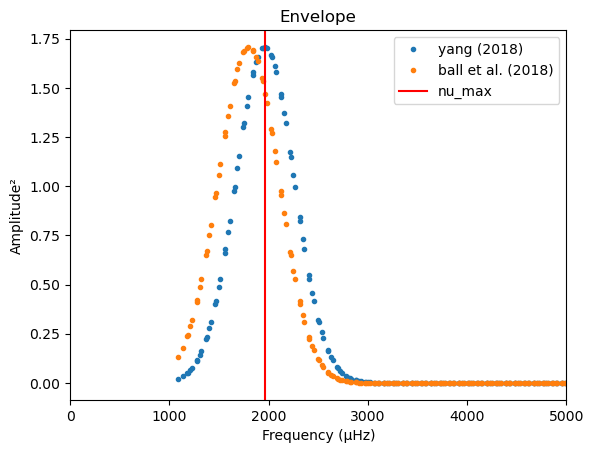

In [34]:
# CHECK: envelope scaled with height
mode_frequency = mode_freq()
y_env = 2*amp_rms_nl_square()/(np.pi*y_linewidths())
env = 2*amp_rms_nl_square()/(np.pi*linewidths(alpha, width_alpha, delta_width_dip, W_dip, nu_dip))
env_ratio = np.max(env)/np.max(y_env)
plt.plot(mode_frequency, y_env*env_ratio, '.', label='yang (2018)')
plt.plot(mode_frequency, env, '.', label='ball et al. (2018)')
plt.axvline(mode_max(), color='r', label='nu_max')
plt.xlabel("Frequency (μHz)")
plt.ylabel("Amplitude²")
plt.xlim(0,5000)
plt.title("Envelope")
plt.legend()
plt.show()

In [35]:
print(env_ratio)

1.8276496480869955


In [36]:
# source: spectrum basics
def power_spec():
    height = height_nl()
    amp_nl = amp_rms_nl_square()   # array
    g = (mass/(radius**2))
    #lw_nl = linewidths()
    lw_nl = linewidths(alpha, width_alpha, delta_width_dip, W_dip, nu_dip)
    nu_nl = mode_freq()
    nu_ac = nu_ac_sun*g*((teff/teff_sun)**(-1/2))   # micro Hz (Chaplin & Miglio 2013)
    #nu_ac = c/(4*np.pi*H)
    #c = nu_ac*4*np.pi*height
    nu_min = 500   # micro Hz
    nu = np.linspace(nu_min, nu_ac, 5000)
    power_of_nu = []
    nl_sum = 0
    for v in nu:
        nl_sum = 0
        for nl in range(len(nu_nl)):
            #p_iter = height[nl]*((lw_nl[nl]/2)**2/((v-nu_nl[nl])**2 + (lw_nl[nl]/2)**2))
            p_iter = height[nl]*((lw_nl[nl]/2)**2/((v-nu_nl[nl])**2 + (lw_nl[nl]/2)**2))
            nl_sum += p_iter
        power_of_nu.append(nl_sum)
    return nu, power_of_nu

# source: spectrum basics
def y_power_spec():
    height = env_ratio*y_height_nl()
    amp_nl = amp_rms_nl_square()   # array
    g = (mass/(radius**2))
    #lw_nl = linewidths()
    lw_nl = y_linewidths()
    nu_nl = mode_freq()
    nu_ac = nu_ac_sun*g*((teff/teff_sun)**(-1/2))   # micro Hz (Chaplin & Miglio 2013)
    #nu_ac = c/(4*np.pi*H)
    #c = nu_ac*4*np.pi*height
    nu_min = 500   # micro Hz
    nu = np.linspace(nu_min, nu_ac, 5000)
    power_of_nu = []
    for v in nu:
        nl_sum = 0
        for nl in range(len(nu_nl)):
            #p_iter = height[nl]*((lw_nl/2)**2/((v-nu_nl[nl])**2 + (lw_nl/2)**2))
            p_iter = height[nl]*((lw_nl/2)**2/((v-nu_nl[nl])**2 + (lw_nl/2)**2))
            nl_sum += p_iter
        power_of_nu.append(nl_sum)
    return nu, power_of_nu

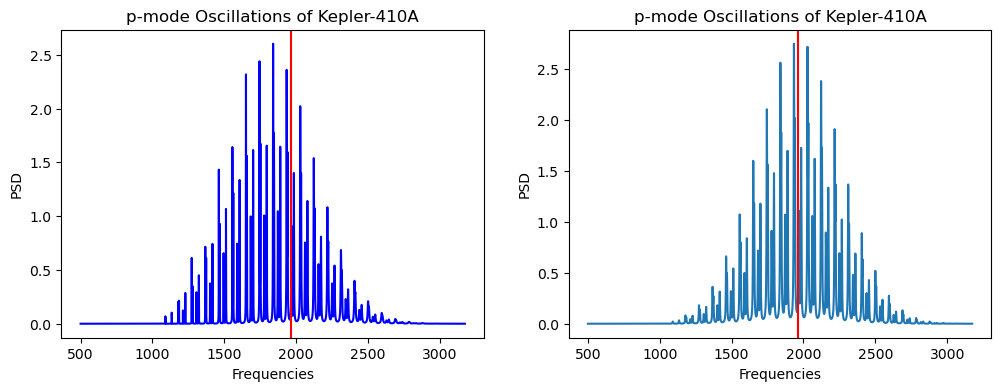

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

frequencies, powers = power_spec()
ax[0].plot(frequencies, powers, c='b')
ax[0].set_xlabel("Frequencies")
ax[0].set_ylabel("PSD")
ax[0].set_title("p-mode Oscillations of Kepler-410A")
ax[0].axvline(mode_max(), c='r')
#plt.xlim(1000,2600)

y_frequencies, y_powers = y_power_spec()
ax[1].plot(y_frequencies, y_powers)
ax[1].set_xlabel("Frequencies")
ax[1].set_ylabel("PSD")
ax[1].set_title("p-mode Oscillations of Kepler-410A")
ax[1].axvline(mode_max(), c='r')
plt.show()

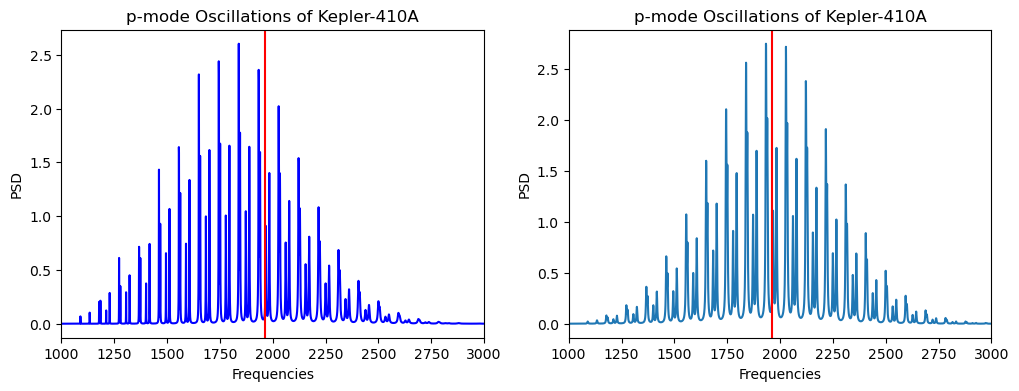

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

frequencies, powers = power_spec()
ax[0].plot(frequencies, powers, c='b')
ax[0].set_xlabel("Frequencies")
ax[0].set_ylabel("PSD")
ax[0].set_title("p-mode Oscillations of Kepler-410A")
ax[0].axvline(mode_max(), c='r')
ax[0].set_xlim(1000,3000)

y_frequencies, y_powers = y_power_spec()
ax[1].plot(y_frequencies, y_powers)
ax[1].set_xlabel("Frequencies")
ax[1].set_ylabel("PSD")
ax[1].set_title("p-mode Oscillations of Kepler-410A")
ax[1].axvline(mode_max(), c='r')
ax[1].set_xlim(1000,3000)
plt.show()

In [39]:
frequencies, powers = power_spec()
ax[0].plot(frequencies, powers, c='b')
ax[0].set_xlabel("Frequencies")
ax[0].set_ylabel("PSD")
ax[0].set_title("p-mode Oscillations of Kepler-410A")
ax[0].axvline(mode_max(), c='r')
ax[0].set_xlim(1000,3000)

(1000.0, 3000.0)

# Candidates

In [21]:
# open the catalogue file (renamed 'PIC.fits')
with fits.open(f'PIC.fits') as hdul:
    primary = hdul[0]   # save primaryHDU
    bintable = hdul[1]   # save bintableHDU
    fits_head = bintable.header   # data headings
    fits_data = bintable.data   # data
    print(len(fits_data))   # print number of entries

309787


In [40]:
'''
takes each of the columns in the fits file (column name defined by headers 'TTYPEX') as an array, and appends that array
to a 'master array', allowing the data to be displayed as an astropy table object.
all column names taken from and meanings explained in 'LOPS2PIC2.1.0.1_DataDefinitionDocument_PLATO-SSDC-PDC-DD-0003.pdf' on canvas.
'''

columns = [[i for i in range(309787)]]   # the master array
for i in range(1,72):   # there are 71 columns total
    #print(i)
    columns.append(fits_data[fits_head[f'TTYPE{i}']])   # append each column as an array, to the master array

# create a table object (purely for display purposes)
pic_table = QTable(columns,
           names=('Index','PICid', 'PICname', 'StarName', 'RAdeg', 'eRAdeg', 'DEdeg', 'eDEdeg', 'pmRA', 'epmRA', 'pmDE', 'epmDE', 'pm', 'epm', 'Plx', 'ePlx', 'distance',
            'edistance', 'Glon', 'Glat', 'posEpoch', 'refEpoch', 'posPropFlag', 'PlatoMagNCAM', 'ePlatoMagNCAM', 'PlatoMagFCAMb', 'ePlatoMagFCAMb',
            'PlatoMagFCAMr', 'ePlatoMagFCAMr', 'Gmag', 'eGmag', 'BPmag', 'eBPmag', 'RPmag', 'eRPmag', 'Hpmag', 'eHpmag', 'Ksmag', 'eKsmag', 'AG', 'eAG',
            'AKs', 'eAKs', 'EBPRP', 'eEBPRP', 'extStatus', 'VmagCalculated', 'eVmagCalculated', 'Teff', 'eTeff', 'Radius', 'eRadius', 'Mass', 'eMass',
            'caseFlag', 'PICmainSourceFlagBOL', 'tPICsourceFlagNCAM_BOL', 'fgPICsourceFlag', 'cPICsourceFlag', 'scvPICsourceFlag', 'NSSFlag',
            'qualityFlag', 'tPICplanetFlag', 'fgPICcPICvariabilityFlag', 'targetStatusFlag', 'BOLrandomSysNSRNCAM_T', 'BOLnCameraObsNCAM_T',
            'BOLnCameraSatNCAM_T', 'tPICscientificRanking', 'scvPICscientificRanking', 'scientificPriority', 'scheduledTarget'),
           meta={'name': 'PIC Table'})

all_index = pic_table['Index']
all_name = pic_table['PICname']
all_mass = pic_table['Mass']
all_radius = pic_table['Radius']
all_teff = pic_table['Teff']

In [41]:
candidates = ['PIC 2915577000081','PIC 2915571000104','PIC 2912861000050','PIC 2908735000056','PIC 2908735000057',
'PIC 2901793000033','PIC 2897612000102','PIC 2893330000017','PIC 2890529000062','PIC 2889072000139',
'PIC 2886168000063','PIC 2886166000078','PIC 2886218000135','PIC 2886191000129','PIC 2883305000009',
'PIC 2880424000123','PIC 2880424000128','PIC 2878914000067','PIC 2878966000167','PIC 2877464000062',
'PIC 2874507000079','PIC 2870094000052','PIC 2868606000109','PIC 2868638000148','PIC 2864154000102',
'PIC 2862637000040','PIC 2861112000105','PIC 2856556000125','PIC 2847353000081','PIC 2844331000233',
'PIC 2841143000066','PIC 2833293000069','PIC 2705309000027']

In [42]:
candi_index = []
candi_name = []
candi_mass = []
candi_radius = []
candi_teff = []
for i in all_index:
    if all_name[i] in candidates:
        #print(f'{all_name[i]} | {all_mass[i]} | {all_radius[i]} | {all_teff[i]}')
        candi_index.append(all_index[i])
        candi_name.append(all_name[i])
        candi_mass.append(all_mass[i])
        candi_radius.append(all_radius[i])
        candi_teff.append(all_teff[i])

In [48]:
# master arrays holding all the plots for each candidate as arrays
candi_freq = []
candi_psd = []

for i in range(len(candi_index)):
    # candidate properties
    name = candi_name[i]
    mass = candi_mass[i]
    radius = candi_radius[i]
    teff = candi_teff[i]
    lum = ((radius)**2)*(teff/teff_sun)**4

    # run model
    frequencies, powers = power_spec()

    # save frequency and psd arrays for this candidate
    candi_freq.append(frequencies)
    candi_psd.append(powers)

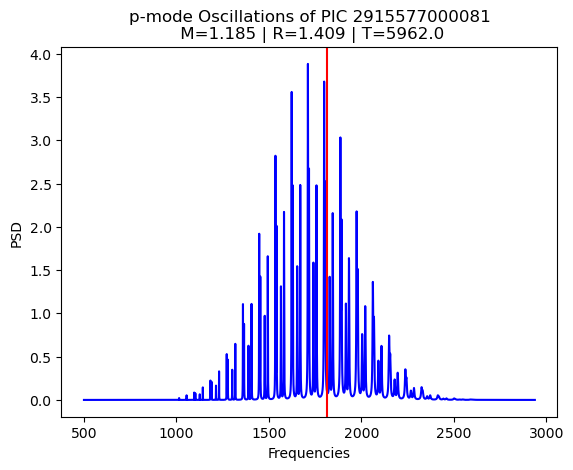

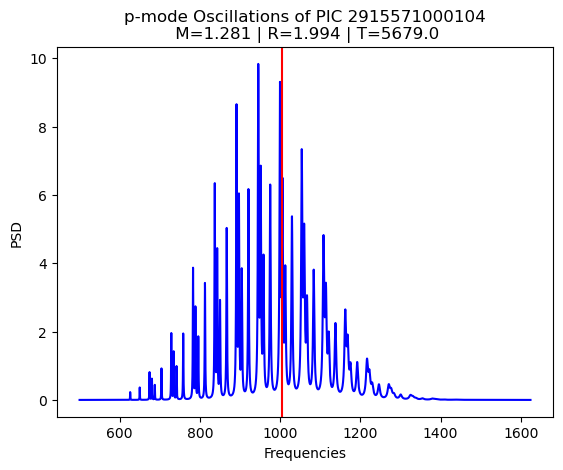

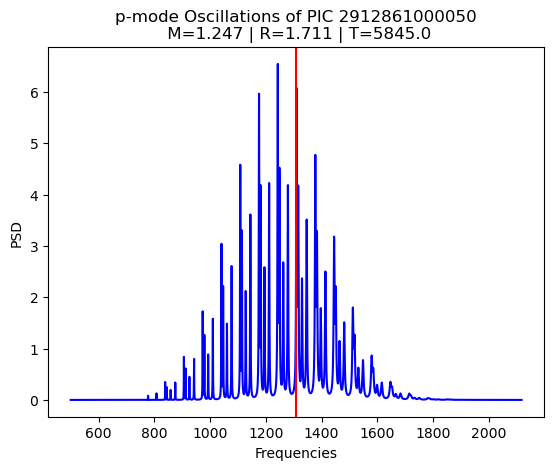

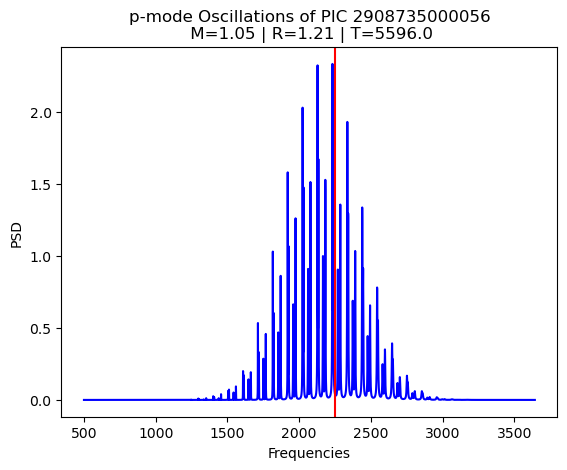

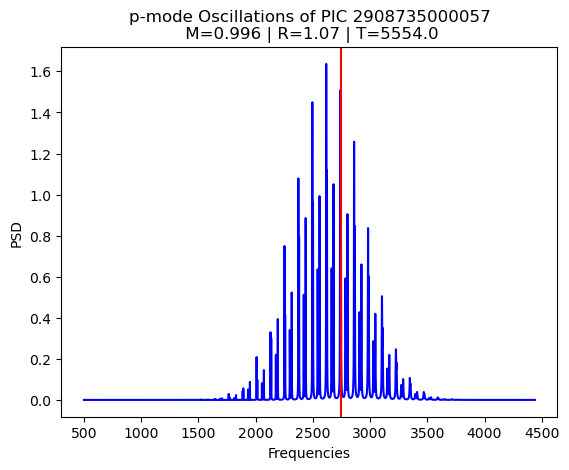

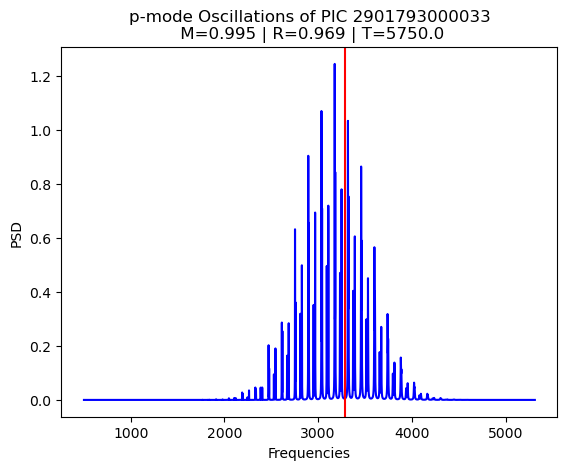

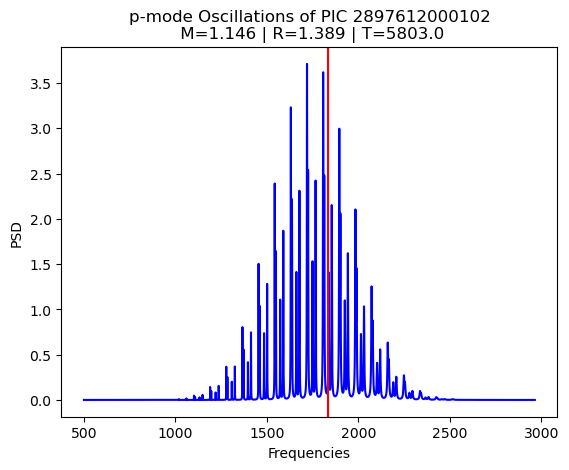

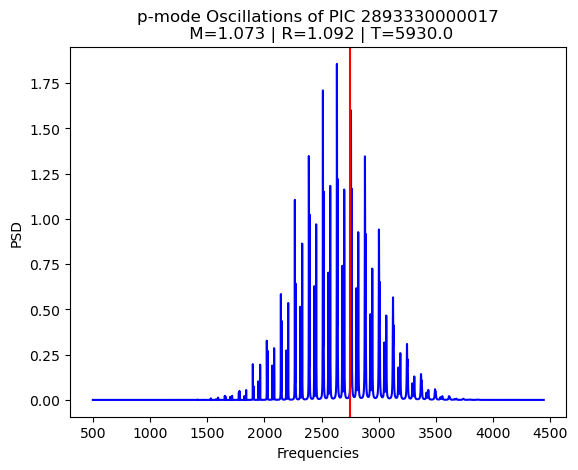

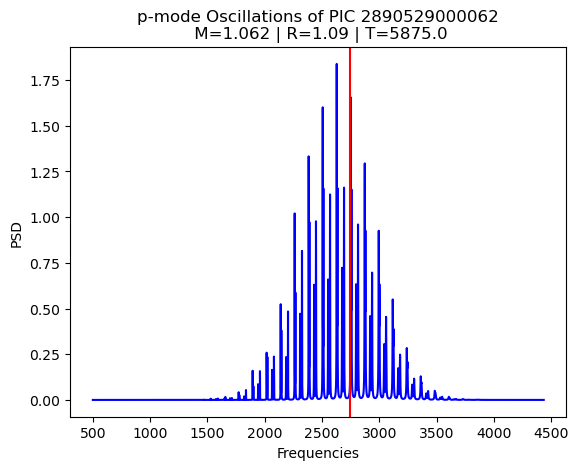

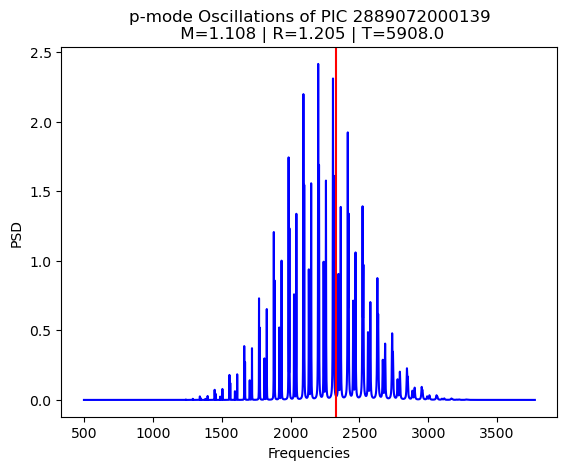

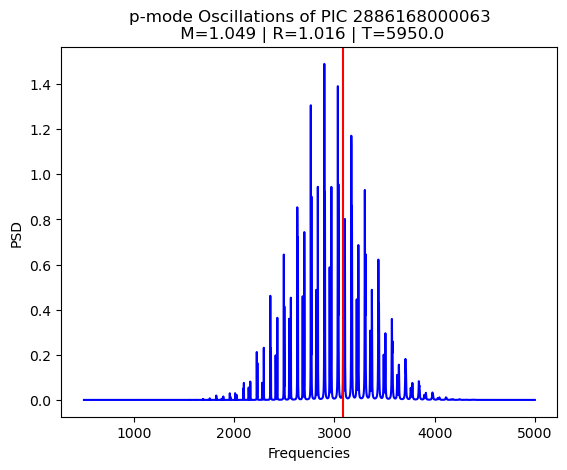

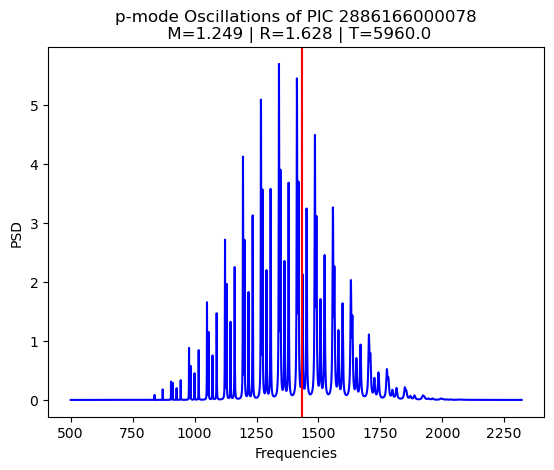

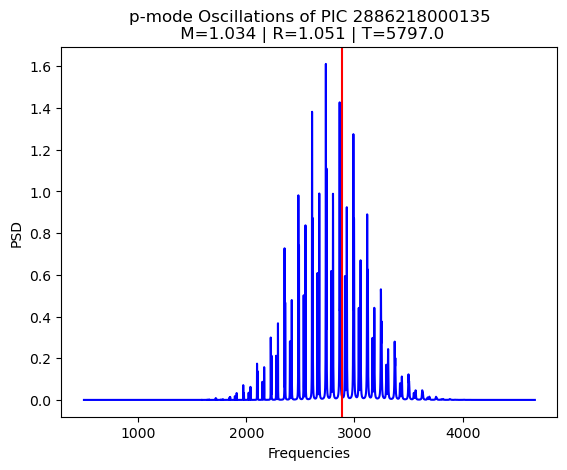

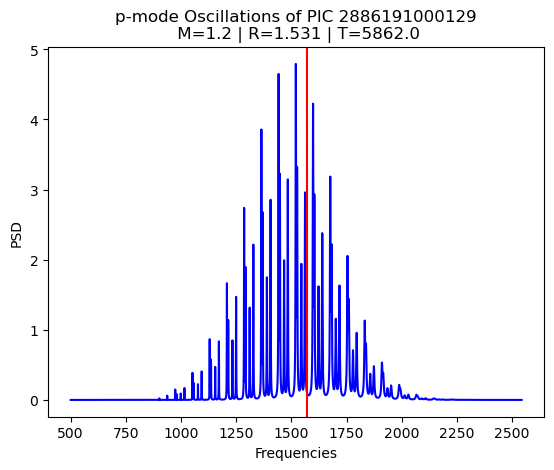

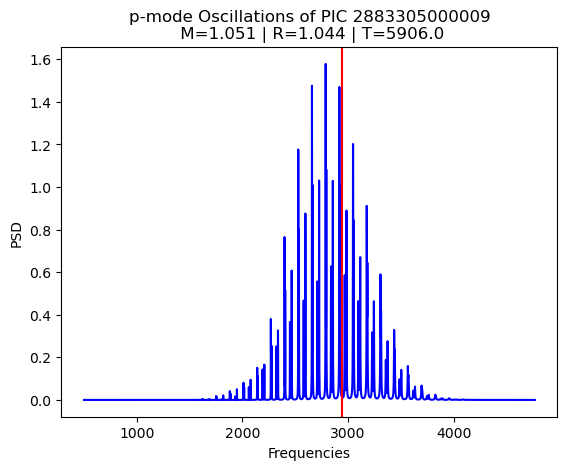

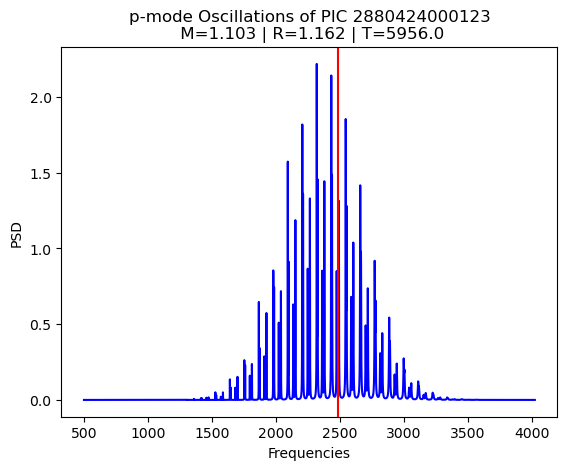

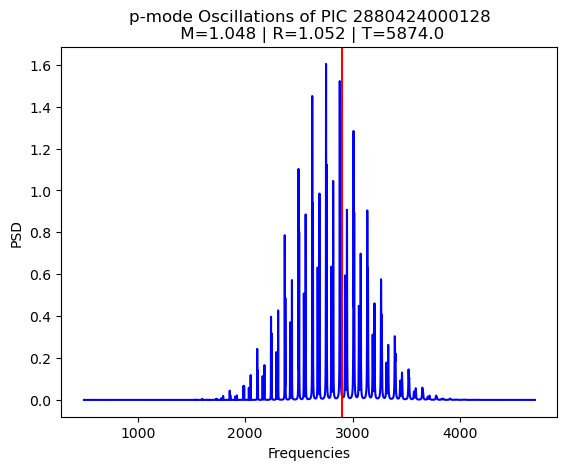

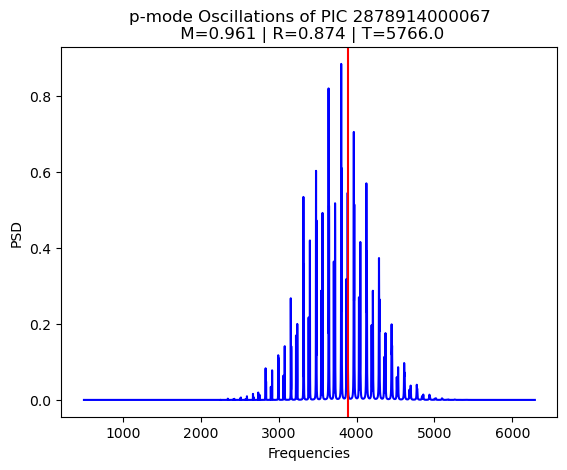

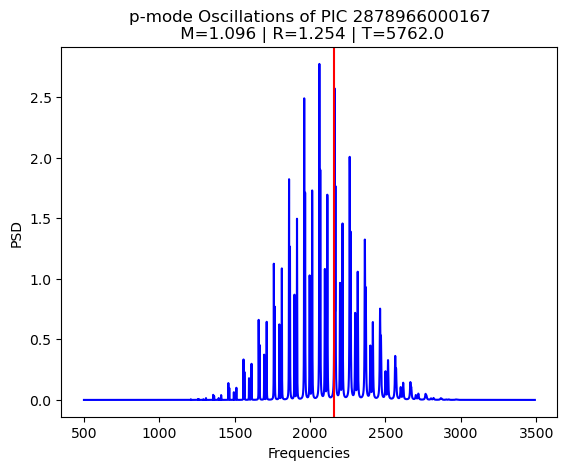

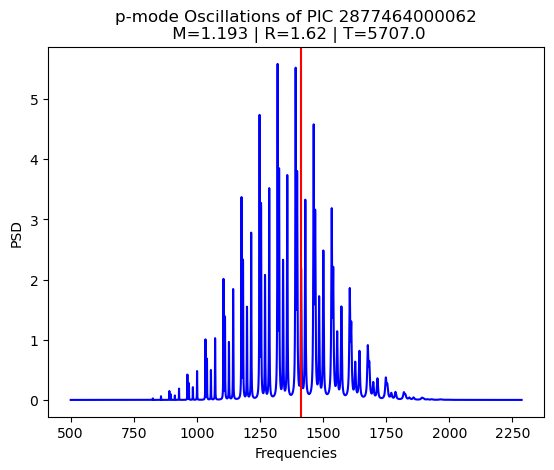

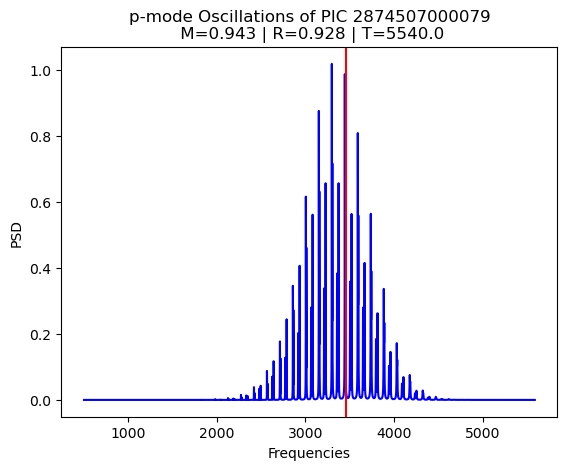

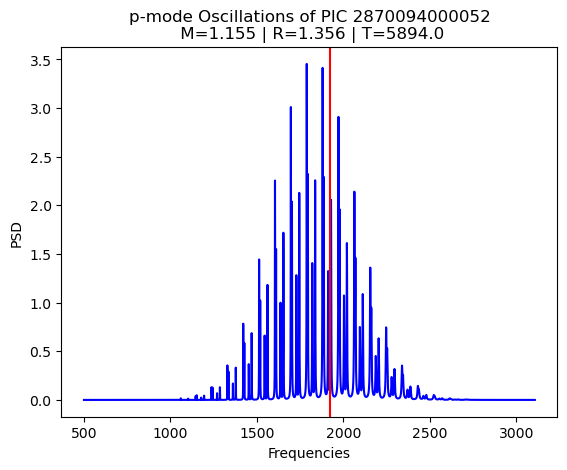

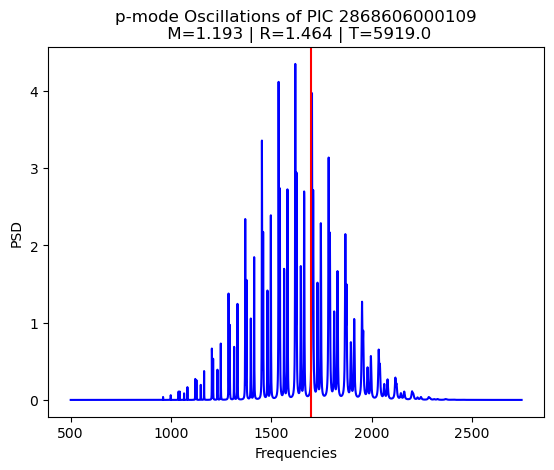

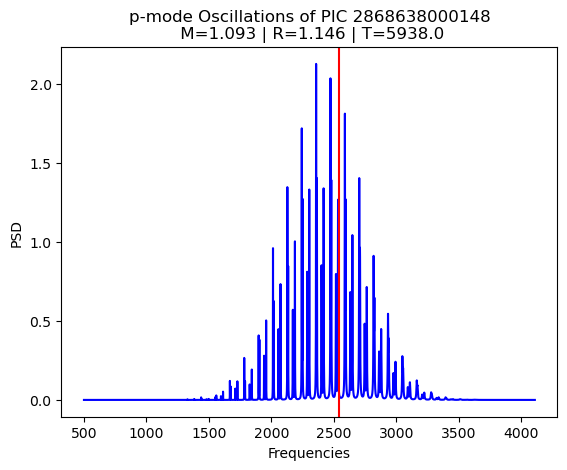

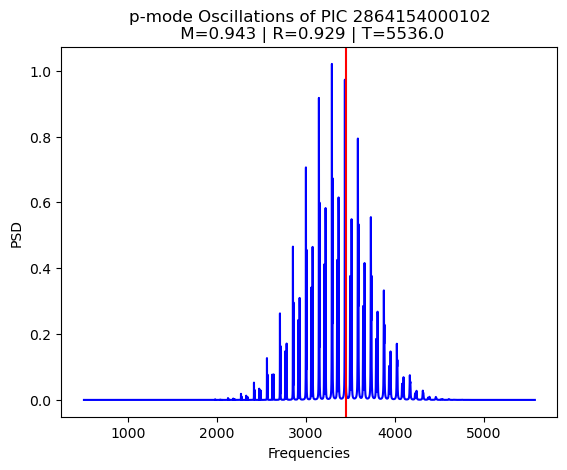

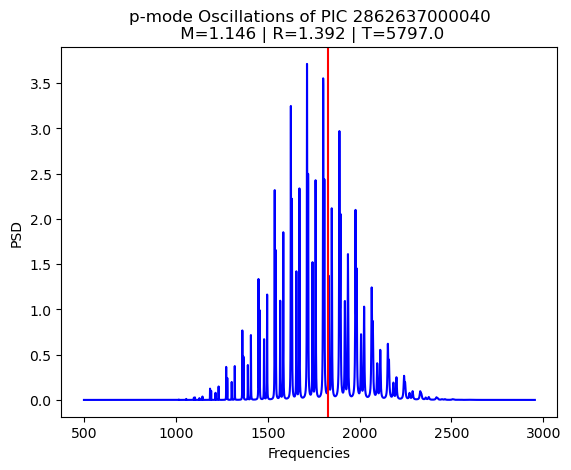

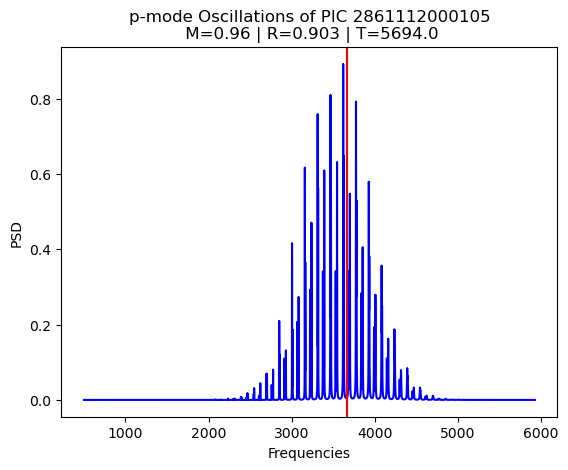

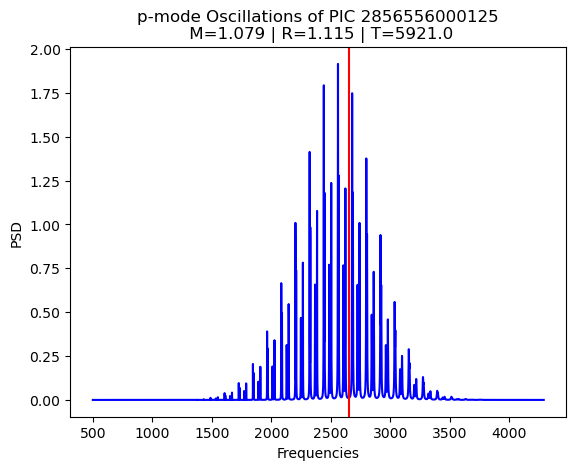

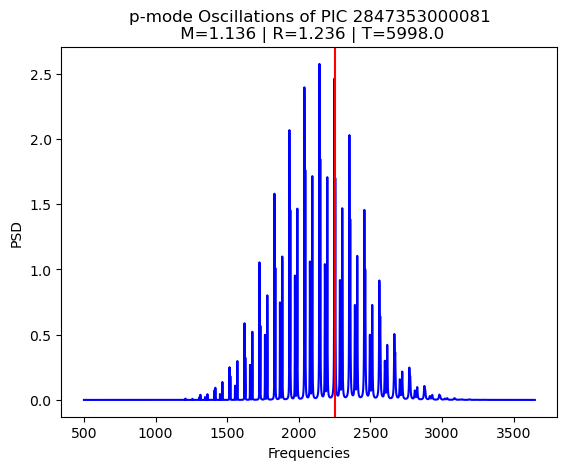

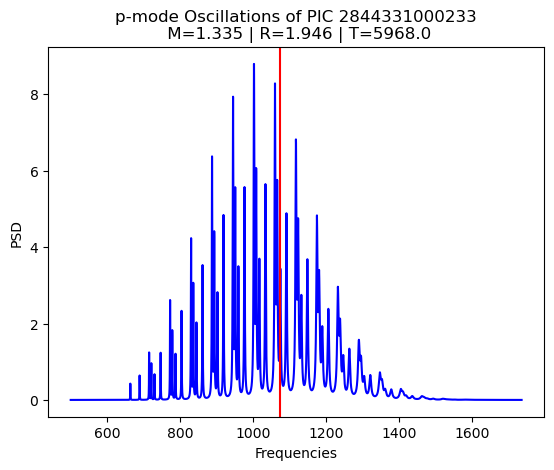

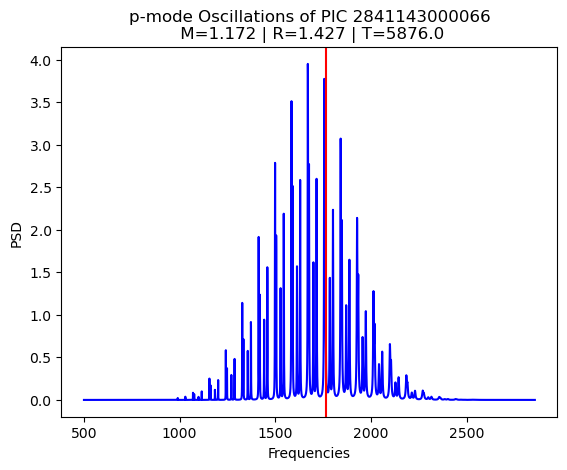

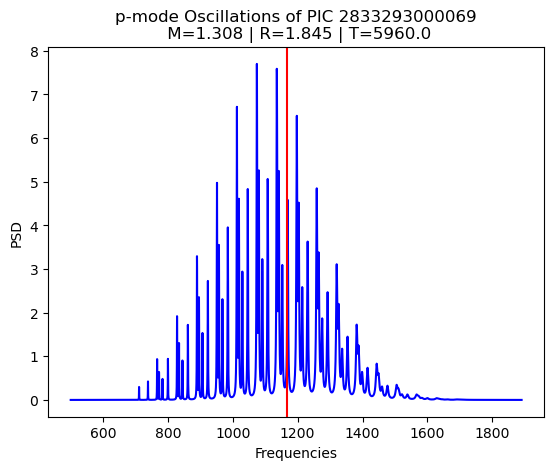

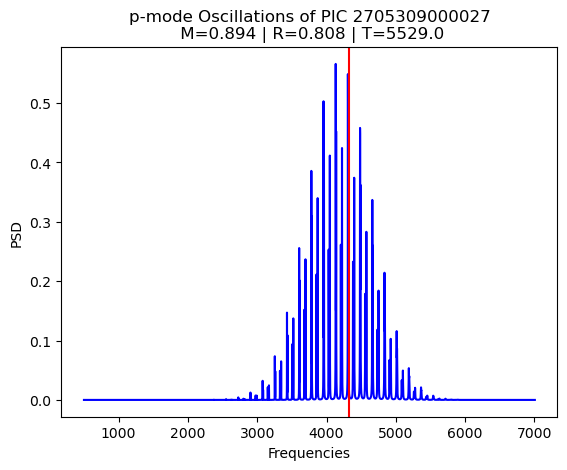

In [51]:
for i in range(len(candi_index)):
    # candidate properties
    name = candi_name[i]
    mass = candi_mass[i]
    radius = candi_radius[i]
    teff = candi_teff[i]

    # plot spectrum for this candidate
    plt.plot(candi_freq[i], candi_psd[i], c='b')
    plt.xlabel("Frequencies")
    plt.ylabel("PSD")
    plt.title(f"p-mode Oscillations of {name}\n M={round(mass,3)} | R={round(radius,3)} | T={round(teff,0)}")
    plt.axvline(mode_max(), c='r')
    #plt.xlim(1000,3000)
    plt.show()